# CLASP cleavage on DBAASP — human serum panel (`35`)

Filter `data/peptides_data/peptides_mic/peptides_apex.csv` to DBAASP sequences and score the
product-variant MEROPS cleavage potential Φ<sub>cleav</sub> against the **human
serum/plasma** protease panel (MEROPS dataset **35**).

CLASP potential uses *A. baumannii* ATCC 19606 activity (mouse infection model
context) with λ = 0.1 by default:

`potential = log2_mic(A. baumannii) + 0.1 · Φ_cleav(serum)`

All **10** design controls live in `data/peptides_data/peptides_mic/controls_mic.csv` (also mirrored as
`data/peptides_data/peptides_mic/omegamp_leads.csv`):
- **OmegAMP** — serum-stable: bZIP-8, pa4-1; serum-labile: Mammutin, GQ20-4, sarcotoxin; all active vs *A. baumannii*
- **Paleogenomics SI** — serum-stable: Mammuthusin-2, Elephasin-2; serum-labile: Hydrodamin-1, Megalocerin-1, Mylodonin-2; MIC / Active from the paper SI (*A. baumannii* ATCC 19606)

Plots start with a **λ sweep** (0.01, 0.05, then 0.1…1.0): for each λ, length vs potential and a
potential histogram with controls highlighted.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src" / "pep_compass").is_dir()),
    cwd,
)
sys.path.insert(0, str(project_root / "src"))

ALL_IN_CSV = project_root / "data" / "peptides_data" / "peptides_mic" / "peptides_apex.csv"
CONTROLS_MIC_CSV = project_root / "data" / "peptides_data" / "peptides_mic" / "controls_mic.csv"
# Same 10-peptide table (legacy path kept in sync).
OMEGAMP_MIC_CSV = project_root / "data" / "peptides_data" / "peptides_mic" / "omegamp_leads.csv"
OUT_DIR = project_root / "experiments" / "results" / "clasp_dbaasp_serum_inspection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Activity matched to the A. baumannii mouse model / OmegAMP assays.
MIC_COLUMN = "A. baumannii ATCC 19606"
MIC_CSV_COLUMN = "MIC_A. baumannii ATCC 19606"
MEROPS_DATASETS = (35,)  # human serum / plasma subset
VARIANT = "product"
LAM = 0.1
DEVICE = "cpu"

# Plot colors by experimental serum fate (cleaved vs not).
STABILITY_COLORS = {
    "stable": "#2ca02c",   # not cleaved / high % remaining
    "labile": "#d62728",   # cleaved / depleted
    "unknown": "#7f7f7f",
}

print("project_root:", project_root)
print("all_in csv:", ALL_IN_CSV, "exists=", ALL_IN_CSV.exists())
print("controls mic:", CONTROLS_MIC_CSV, "exists=", CONTROLS_MIC_CSV.exists())
print("MIC_COLUMN:", MIC_COLUMN, "MEROPS:", MEROPS_DATASETS, "LAM:", LAM)

project_root: /home/max/repositories/pep-compass
all_in csv: /home/max/repositories/pep-compass/data/peptides_data/peptides_mic/peptides_apex.csv exists= True
controls mic: /home/max/repositories/pep-compass/data/peptides_data/peptides_mic/controls_mic.csv exists= True
MIC_COLUMN: A. baumannii ATCC 19606 MEROPS: (35,) LAM: 0.1


In [7]:
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    load_protease_panel,
)

raw = pd.read_csv(ALL_IN_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
dbaasp = (
    raw[raw["dataset"].str.contains("dbaasp", case=False, na=False)]
    .drop_duplicates(subset=["sequence"])
    .reset_index(drop=True)
)
dbaasp["length"] = dbaasp["sequence"].str.len()
dbaasp["mic_uM"] = dbaasp[MIC_COLUMN].astype(float)
dbaasp["log2_mic"] = np.log2(dbaasp["mic_uM"])
dbaasp["mic_source"] = "apex_all_in"

print(f"DBAASP peptides: {len(dbaasp)} (unique sequences)")
print(dbaasp["length"].describe().round(2))

DBAASP peptides: 3038 (unique sequences)
count    3038.00
mean       16.86
std         4.35
min        10.00
25%        13.00
50%        17.00
75%        20.00
max        25.00
Name: length, dtype: float64


In [8]:
panel = load_protease_panel(MEROPS_DATASETS, device=DEVICE)
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)
print(f"panel proteases: {panel.matrices.shape[0]}")

phi = (
    cleavage.sequence_log_potential(dbaasp["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
)
dbaasp["cleavage"] = phi.astype(float)                 # Φ_cleav (product, serum)
dbaasp["cleavage_term"] = LAM * dbaasp["cleavage"]     # λ · Φ_cleav
dbaasp["potential"] = dbaasp["log2_mic"] + dbaasp["cleavage_term"]

out_csv = OUT_DIR / "dbaasp_serum_cleavage.csv"
dbaasp.to_csv(out_csv, index=False)
print("wrote", out_csv)
dbaasp[["sequence", "length", "log2_mic", "cleavage", "cleavage_term", "potential"]].head()

panel proteases: 55
wrote /home/max/repositories/pep-compass/experiments/results/clasp_dbaasp_serum_inspection/dbaasp_serum_cleavage.csv


,sequence,length,log2_mic,cleavage,cleavage_term,potential
0,AAARLRLLLYLITRR,15,6.275612,-14.967207,-1.496721,4.778891
1,AAHCIALRKGYK,12,6.836153,-16.842422,-1.684242,5.151911
2,AAHCIQLGKR,10,7.067360,-17.267506,-1.726751,5.340609
3,AAHCIVLHHN,10,7.094323,-18.219025,-1.821902,5.272420
4,AAHCLAIGRK,10,6.981992,-16.749714,-1.674971,5.307020


## Descriptive statistics — cleavage potential Φ<sub>cleav</sub>

Median, all deciles (P10…P90), quartiles, mean, variance / std, IQR, range,
and skewness / kurtosis of the product-variant serum cleavage potential.

In [9]:
x = dbaasp["cleavage"].to_numpy()
deciles = {f"p{p}": float(np.percentile(x, p)) for p in range(10, 100, 10)}
stats = {
    "n": int(x.size),
    "mean": float(np.mean(x)),
    "median": float(np.median(x)),
    "std": float(np.std(x, ddof=1)),
    "variance": float(np.var(x, ddof=1)),
    "mad": float(np.median(np.abs(x - np.median(x)))),
    "iqr": float(np.percentile(x, 75) - np.percentile(x, 25)),
    "min": float(np.min(x)),
    "max": float(np.max(x)),
    "range": float(np.max(x) - np.min(x)),
    "q1": float(np.percentile(x, 25)),
    "q3": float(np.percentile(x, 75)),
    **deciles,
    "skewness": float(pd.Series(x).skew()),
    "kurtosis_excess": float(pd.Series(x).kurtosis()),
}
stats_df = pd.DataFrame({"metric": list(stats.keys()), "value": list(stats.values())})
stats_path = OUT_DIR / "cleavage_descriptive_stats.csv"
stats_df.to_csv(stats_path, index=False)
print(stats_df.to_string(index=False))
print("wrote", stats_path)

         metric       value
              n 3038.000000
           mean  -16.202919
         median  -16.202054
            std    0.993891
       variance    0.987819
            mad    0.642561
            iqr    1.287739
            min  -19.080654
            max  -12.230506
          range    6.850148
             q1  -16.854582
             q3  -15.566844
            p10  -17.527981
            p20  -17.039382
            p30  -16.670493
            p40  -16.424815
            p50  -16.202054
            p60  -15.958316
            p70  -15.703831
            p80  -15.395727
            p90  -14.913935
       skewness    0.082913
kurtosis_excess    0.113103
wrote /home/max/repositories/pep-compass/experiments/results/clasp_dbaasp_serum_inspection/cleavage_descriptive_stats.csv


## Serum controls (10 peptides)

Score controls with serum Φ<sub>cleav</sub>. Prefer **experimental** *A. baumannii*
ATCC 19606 MIC from `data/peptides_data/peptides_mic/controls_mic.csv`; fall back to APEX when MIC is
missing (`N.A.` in the paleogenomics SI).

| Name | Sequence | Serum fate | MIC (µM) | Active |
|---|---|---|---|---|
| Ω-AP-Mammutin-1-4 | `WKRIKALRLSLRFKL` | labile | 8 | yes |
| Ω-MT-bZIP-8 | `RAGLKKVVKVLKKGNKDLQRLVEKLLQRVA` | stable | 0.5 | yes |
| Ω-AU-GQ20-4 | `GKLRRWIRKLFRKFKEKFAK` | labile | 4 | yes |
| Ω-AMT-pa4-1 | `GFFALIPKIISKPALKKLLSAVGSGLSSISGKE` | stable | 0.5 | yes |
| Ω-AMT-sarcotoxin-4 | `GWLKKIGKKIERVGQTTRDATIQALGIAQQAANVAATAR` | labile | 1 | yes |
| Mammuthusin-2 | `LILSLLINSTLALL` | stable | N.A. | no |
| Hydrodamin-1 | `ILTLFIIFQLKISKL` | labile | N.A. | yes |
| Megalocerin-1 | `KKPPNPIKPKVPLSAPRKSPNTVKYRLKFR` | labile | 32 | yes |
| Elephasin-2 | `VFLTLNSIKVLKL` | stable | N.A. | no |
| Mylodonin-2 | `FLLLLFLSHLIL` | labile | N.A. | no |

Among the paleogenomics five, only **Mammuthusin-2** and **Elephasin-2** are
serum-stable (not cleaved). Higher % remaining ≈ stable; depletion ≈ labile.

In [10]:
from pep_compass.optimization.components.oracles.strategies.apex_original.predictor import PredictorAPEX

# Unified 10-peptide DB: sequences, serum fate, active, experimental MIC.
controls = pd.read_csv(CONTROLS_MIC_CSV)
assert len(controls) == 10, f'expected 10 controls, got {len(controls)}'

phi_ctrl = (
    cleavage.sequence_log_potential(controls['sequence'].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
controls['cleavage'] = phi_ctrl
controls['cleavage_term'] = LAM * controls['cleavage']

# Experimental label: stable <=> not cleaved; labile <=> cleaved.
controls['cleaved'] = controls['serum_fate'].map(
    {'stable': False, 'labile': True, 'unknown': pd.NA}
)

# Prefer experimental A. baumannii MIC; else APEX. Keep paper active label.
controls['mic_uM'] = pd.to_numeric(controls[MIC_CSV_COLUMN], errors='coerce')
controls['mic_source'] = np.where(controls['mic_uM'].notna(), 'experimental', pd.NA)
controls['active'] = controls['active'].astype(bool)

need_pred = controls['mic_uM'].isna()
if need_pred.any():
    apex = PredictorAPEX(device=DEVICE, model='full')
    mic_idx = apex.pathogen_list.index(MIC_COLUMN)
    pred = apex.predict(controls.loc[need_pred, 'sequence'].tolist())
    controls.loc[need_pred, 'mic_uM'] = pred[:, mic_idx]
    controls.loc[need_pred, 'mic_source'] = 'apex'

controls['log2_mic'] = np.log2(controls['mic_uM'].astype(float))
controls['potential'] = controls['log2_mic'] + controls['cleavage_term']

phi_ref = np.sort(dbaasp['cleavage'].to_numpy())
controls['dbaasp_percentile'] = [
    100.0 * float(np.searchsorted(phi_ref, v, side='right') / len(phi_ref))
    for v in controls['cleavage']
]
controls['in_dbaasp'] = controls['sequence'].isin(set(dbaasp['sequence']))
controls['ctrl_color'] = controls['serum_fate'].map(STABILITY_COLORS)

ctrl_path = OUT_DIR / 'serum_controls_cleavage.csv'
controls.to_csv(ctrl_path, index=False)

print(
    controls[
        [
            'name', 'short', 'source', 'serum_fate', 'cleaved', 'active',
            'mic_uM', 'mic_source', 'cleavage', 'dbaasp_percentile', 'potential',
        ]
    ].to_string(index=False)
)
print('wrote', ctrl_path)

# Predicted vs experimental serum fate (all annotated controls).
ranked = controls.copy()
ranked['pred_rank_labile'] = ranked['cleavage'].rank(ascending=False)
print('\\nHigher Phi_cleav = predicted more labile')
print(
    ranked[
        ['short', 'serum_fate', 'active', 'mic_uM', 'mic_source',
         'cleavage', 'dbaasp_percentile', 'pred_rank_labile']
    ]
    .sort_values('cleavage', ascending=False)
    .to_string(index=False)
)


              name         short           source serum_fate cleaved  active    mic_uM   mic_source   cleavage  dbaasp_percentile  potential
 Ω-AP-Mammutin-1-4      Mammutin          OmegAMP     labile    True    True  8.000000 experimental -15.780283          67.445688   1.421972
       Ω-MT-bZIP-8        bZIP-8          OmegAMP     stable   False    True  0.500000 experimental -14.826915          91.145490  -2.482691
       Ω-AU-GQ20-4        GQ20-4          OmegAMP     labile    True    True  4.000000 experimental -16.321283          44.371297   0.367872
       Ω-AMT-pa4-1         pa4-1          OmegAMP     stable   False    True  0.500000 experimental -14.259536          97.531271  -2.425954
Ω-AMT-sarcotoxin-4    sarcotoxin          OmegAMP     labile    True    True  1.000000 experimental -15.091079          87.261356  -1.509108
     Mammuthusin-2 Mammuthusin-2 Paleogenomics SI     stable   False   False 75.028137         apex -16.164446          51.678736   4.612915
      Hydroda

## λ sweep: length vs potential + histogram

For each λ ∈ {0.01, 0.05, 0.1, 0.2, …, 1.0}:

`potential(λ) = log2_mic(A. baumannii) + λ · Φ_cleav(serum)`

Top panel: length vs potential (DBAASP + controls). Bottom panel: potential
histogram with the same controls marked. Green = serum-stable, red = serum-labile;
filled circles = active, crosses = inactive.

LAMBDAS: [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


KeyError: 'length'

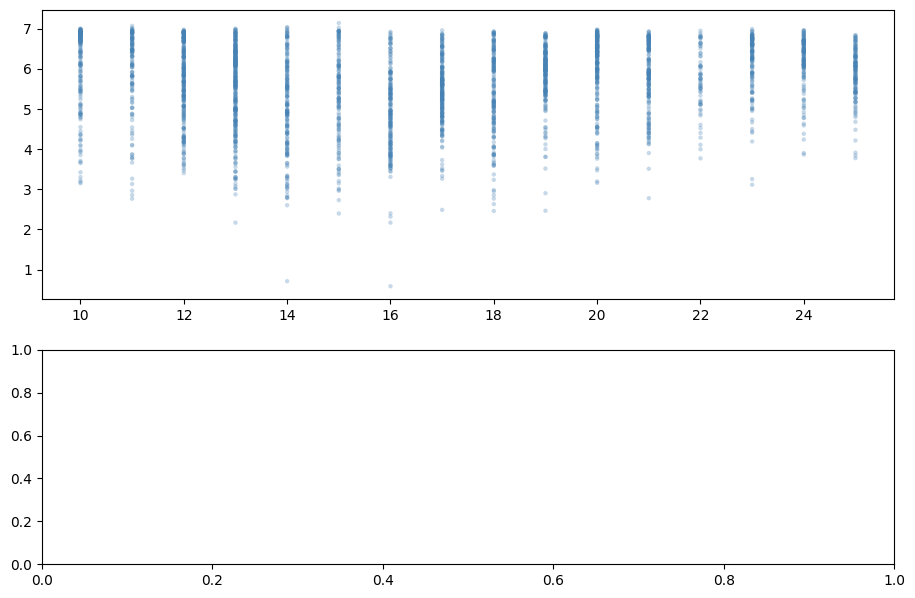

In [11]:
LAMBDAS = [0.01, 0.05] + [round(x, 1) for x in np.arange(0.1, 1.01, 0.1)]
print("LAMBDAS:", LAMBDAS)

def _overlay_controls_scatter_xy(ax, frame, x_col, y_col):
    for _, row in frame.iterrows():
        active = bool(row["active"])
        ax.scatter(
            row[x_col],
            row[y_col],
            s=90 if active else 55,
            c=row["ctrl_color"],
            marker="o" if active else "x",
            edgecolors="black" if active else row["ctrl_color"],
            linewidths=0.8,
            zorder=3,
        )
        ax.annotate(
            row["short"],
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=7,
            color=row["ctrl_color"],
            zorder=4,
        )


def _overlay_controls_vlines(ax, frame, values, labels):
    y_hi = ax.get_ylim()[1]
    y_fracs = np.linspace(0.92, 0.28, len(frame))
    for i, (_, row) in enumerate(frame.iterrows()):
        color = row["ctrl_color"]
        ax.axvline(values.iloc[i], color=color, lw=1.8, alpha=0.9, zorder=2)
        ax.text(
            values.iloc[i],
            y_hi * y_fracs[i],
            labels.iloc[i],
            rotation=90,
            va="top",
            ha="right",
            fontsize=7,
            color=color,
            zorder=3,
        )


legend_scatter = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=6, label="DBAASP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=STABILITY_COLORS["stable"],
           markeredgecolor="black", markersize=7, label="stable + active"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=STABILITY_COLORS["labile"],
           markeredgecolor="black", markersize=7, label="labile + active"),
    Line2D([0], [0], marker="x", color=STABILITY_COLORS["stable"],
           markersize=7, label="stable + inactive"),
    Line2D([0], [0], marker="x", color=STABILITY_COLORS["labile"],
           markersize=7, label="labile + inactive"),
]
legend_hist = [
    Line2D([0], [0], color="lightgray", lw=8, label="DBAASP"),
    Line2D([0], [0], color="black", ls="--", lw=1.2, label="median"),
    Line2D([0], [0], color=STABILITY_COLORS["stable"], lw=2, label="stable / not cleaved"),
    Line2D([0], [0], color=STABILITY_COLORS["labile"], lw=2, label="labile / cleaved"),
]

for lam in LAMBDAS:
    pot = dbaasp["log2_mic"] + lam * dbaasp["cleavage"]
    ctrl_pot = controls["log2_mic"] + lam * controls["cleavage"]

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(11, 7.2),
        gridspec_kw={"height_ratios": [1.35, 1.0]},
    )

    ax = axes[0]
    ax.scatter(
        dbaasp["length"],
        pot,
        s=10,
        alpha=0.30,
        c="steelblue",
        edgecolors="none",
        zorder=1,
    )
    ctrl_view = controls.copy()
    ctrl_view["potential_lam"] = ctrl_pot.to_numpy()
    _overlay_controls_scatter_xy(ax, ctrl_view, "length", "potential_lam")
    rho = dbaasp["length"].corr(pot, method="spearman")
    ax.text(
        0.02,
        0.98,
        f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
    )
    ax.set_xlabel("peptide length")
    ax.set_ylabel(rf"$\log_2\mathrm{{MIC}} + {lam:g}\,\Phi_{{\mathrm{{cleav}}}}$")
    ax.set_title(rf"Length vs CLASP potential  ($\lambda = {lam:g}$)")
    ax.legend(handles=legend_scatter, loc="best", fontsize=7)

    ax = axes[1]
    ax.hist(pot, bins=40, color="lightgray", edgecolor="white", alpha=0.95, zorder=1)
    med = float(np.median(pot))
    ax.axvline(med, color="black", ls="--", lw=1.2, zorder=2)
    _overlay_controls_vlines(
        ax,
        controls,
        ctrl_pot.reset_index(drop=True),
        controls["short"].reset_index(drop=True),
    )
    ax.set_xlabel(
        rf"$\log_2\mathrm{{MIC}}(A.\,baumannii) + {lam:g}\,\Phi_{{\mathrm{{cleav}}}}$"
    )
    ax.set_ylabel("count")
    ax.set_title(rf"Potential histogram  ($\lambda = {lam:g}$)")
    ax.legend(handles=legend_hist, loc="upper left", fontsize=7)

    fig.tight_layout()
    out = OUT_DIR / f"lambda_sweep_length_potential_hist_lam_{str(lam).replace('.', 'p')}.png"
    fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print("wrote", out)


## Histograms: Φ<sub>cleav</sub> and CLASP potential (λ = 0.1)

Green = experimentally **serum-stable** (not cleaved); red = **serum-labile**
(cleaved). Potential uses *A. baumannii* MIC (experimental when available, else APEX).

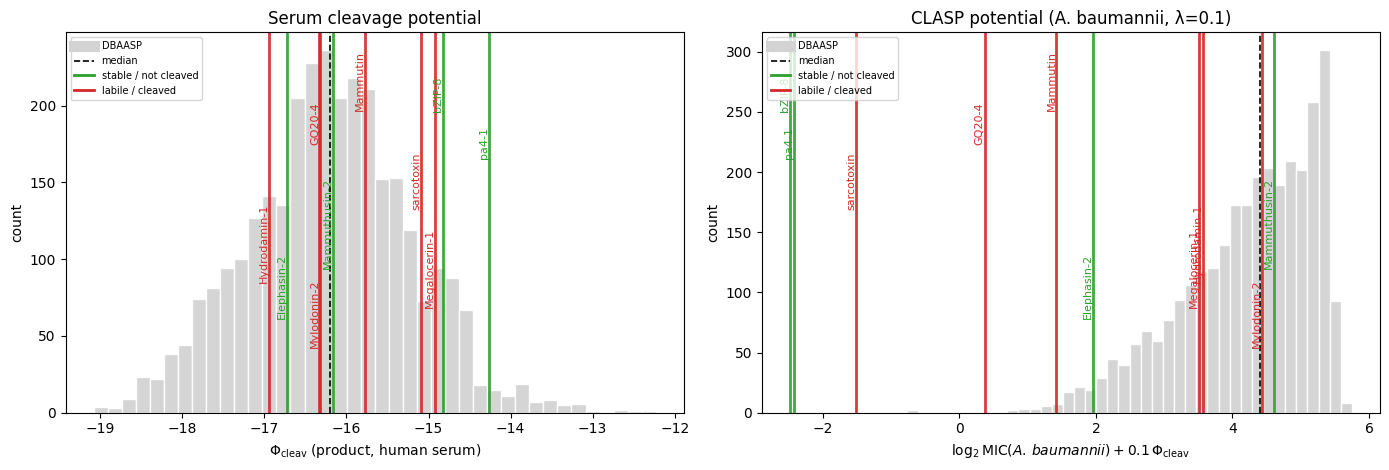

In [ ]:
def overlay_controls_vlines(ax, frame, value_col):
    y_fracs = np.linspace(0.95, 0.35, len(frame))
    for i, (_, row) in enumerate(frame.iterrows()):
        color = row["ctrl_color"]
        ax.axvline(row[value_col], color=color, lw=2.0, alpha=0.9)
        ax.text(
            row[value_col],
            ax.get_ylim()[1] * y_fracs[i],
            row["short"],
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color=color,
        )


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.hist(dbaasp["cleavage"], bins=40, color="lightgray", edgecolor="white", alpha=0.95)
overlay_controls_vlines(ax, controls, "cleavage")
ax.axvline(stats["median"], color="black", ls="--", lw=1.2)
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product, human serum)")
ax.set_ylabel("count")
ax.set_title("Serum cleavage potential")

ax = axes[1]
ax.hist(dbaasp["potential"], bins=40, color="lightgray", edgecolor="white", alpha=0.95)
overlay_controls_vlines(ax, controls, "potential")
pot_med = float(dbaasp["potential"].median())
ax.axvline(pot_med, color="black", ls="--", lw=1.2)
ax.set_xlabel(r"$\log_2\mathrm{MIC}(A.\,baumannii) + 0.1\,\Phi_{\mathrm{cleav}}$")
ax.set_ylabel("count")
ax.set_title("CLASP potential (A. baumannii, λ=0.1)")

legend_handles = [
    Line2D([0], [0], color="lightgray", lw=8, label="DBAASP"),
    Line2D([0], [0], color="black", ls="--", lw=1.2, label="median"),
    Line2D([0], [0], color=STABILITY_COLORS["stable"], lw=2, label="stable / not cleaved"),
    Line2D([0], [0], color=STABILITY_COLORS["labile"], lw=2, label="labile / cleaved"),
]
for ax in axes:
    ax.legend(handles=legend_handles, loc="upper left", fontsize=7)

fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_and_potential_histograms.png", dpi=150)
plt.show()


## Scatter: length vs Φ<sub>cleav</sub> and length vs potential

Same quantities vs length. Marker color = serum fate; filled circles = paper
**active** vs *A. baumannii*; crosses = inactive / no activity.

C:\Users\Karol\AppData\Local\Temp\ipykernel_23464\1302906178.py:4: UserWarning: You passed a edgecolor/edgecolors ('#2ca02c') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Karol\AppData\Local\Temp\ipykernel_23464\1302906178.py:4: UserWarning: You passed a edgecolor/edgecolors ('#d62728') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


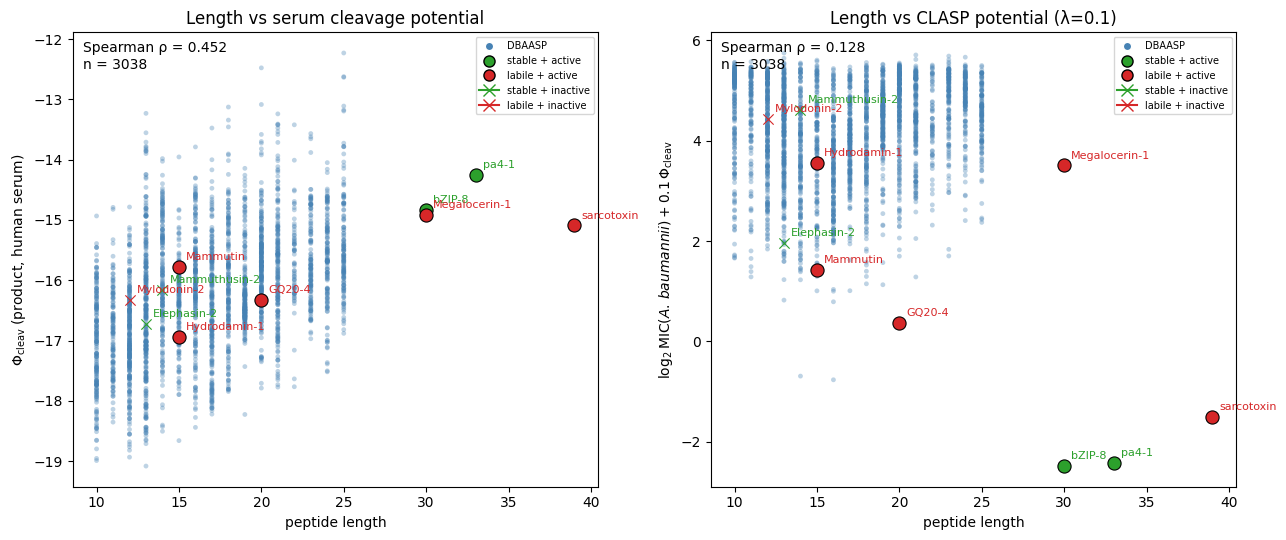

In [ ]:
def overlay_controls_scatter(ax, frame, y_col):
    for _, row in frame.iterrows():
        active = row["active"] is True or row["active"] == True
        ax.scatter(
            row["length"],
            row[y_col],
            s=90 if active else 55,
            c=row["ctrl_color"],
            marker="o" if active else "x",
            edgecolors="black" if active else row["ctrl_color"],
            linewidths=0.8,
            zorder=3,
        )
        ax.annotate(
            row["short"],
            (row["length"], row[y_col]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
            color=row["ctrl_color"],
            zorder=4,
        )


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(
    dbaasp["length"], dbaasp["cleavage"],
    s=12, alpha=0.35, c="steelblue", edgecolors="none", zorder=1,
)
overlay_controls_scatter(ax, controls, "cleavage")
rho = dbaasp["length"].corr(dbaasp["cleavage"], method="spearman")
ax.text(0.02, 0.98, f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
        transform=ax.transAxes, va="top", fontsize=10)
ax.set_xlabel("peptide length")
ax.set_ylabel(r"$\Phi_{\mathrm{cleav}}$ (product, human serum)")
ax.set_title("Length vs serum cleavage potential")

ax = axes[1]
ax.scatter(
    dbaasp["length"], dbaasp["potential"],
    s=12, alpha=0.35, c="steelblue", edgecolors="none", zorder=1,
)
overlay_controls_scatter(ax, controls, "potential")
rho = dbaasp["length"].corr(dbaasp["potential"], method="spearman")
ax.text(0.02, 0.98, f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
        transform=ax.transAxes, va="top", fontsize=10)
ax.set_xlabel("peptide length")
ax.set_ylabel(r"$\log_2\mathrm{MIC}(A.\,baumannii) + 0.1\,\Phi_{\mathrm{cleav}}$")
ax.set_title("Length vs CLASP potential (λ=0.1)")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=6, label="DBAASP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=STABILITY_COLORS["stable"],
           markeredgecolor="black", markersize=8, label="stable + active"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=STABILITY_COLORS["labile"],
           markeredgecolor="black", markersize=8, label="labile + active"),
    Line2D([0], [0], marker="x", color=STABILITY_COLORS["stable"],
           markersize=8, label="stable + inactive"),
    Line2D([0], [0], marker="x", color=STABILITY_COLORS["labile"],
           markersize=8, label="labile + inactive"),
]
for ax in axes:
    ax.legend(handles=legend_handles, loc="best", fontsize=7)

fig.tight_layout()
fig.savefig(OUT_DIR / "length_vs_cleavage_and_potential_scatter.png", dpi=150)
plt.show()


## Mutation ΔΦ<sub>cleav</sub> heatmaps (serum controls)

Same single-substitution scan as in the *S. aureus* notebook, but with the
**human serum** protease panel. Lower panel shows wild-type per-bond
contributions to Φ<sub>cleav</sub>.

No literature cut sites are marked for these design peptides (unknown / not
compiled here); the bond bar still shows where the serum panel predicts the
highest cleavage mass.

In [ ]:
import importlib
import pep_compass.optimization.components.helpers.proteolysis.cleavage as _mp

importlib.reload(_mp)
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    MEROPS_AMINO_ACIDS,
)

# Rebuild so this kernel picks up sequence_bond_contributions after code changes.
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)

AA_LIST = list(MEROPS_AMINO_ACIDS)
AA_IDX = [cleavage.alphabet.index(aa) for aa in AA_LIST]


def mutation_delta_matrix(sequence: str) -> np.ndarray:
    """Return (20 aa x L) matrix of ΔΦ_cleav = Φ(mut) - Φ(parent)."""
    length = len(sequence)
    mutations = {pos: AA_IDX for pos in range(length)}
    scores = cleavage.compute(sequence, mutations)
    mat = np.zeros((len(AA_LIST), length), dtype=np.float64)
    for pos in range(length):
        for aa_i, aa in enumerate(AA_LIST):
            mat[aa_i, pos] = scores[pos][AA_IDX[aa_i]]
    return mat


def plot_control_heatmap(
    sequence: str,
    title: str,
    out_path: Path,
    known_bonds: list | None = None,
    bond_contrib: np.ndarray | None = None,
):
    """Heatmap of position x replacement ΔΦ_cleav, optional cut sites + bond bars.

    known_bonds: list of (bond_index, label) where bond_index is 0-based cut
    between residues bond_index and bond_index+1 (P1 | P1').
    """
    mat = mutation_delta_matrix(sequence)
    length = len(sequence)
    known_bonds = known_bonds or []

    # Diverging scale centered at 0 (negative Δ = more stable).
    vmax = float(np.nanmax(np.abs(mat))) if mat.size else 1.0
    vmax = max(vmax, 1e-6)

    n_panels = 2 if bond_contrib is not None else 1
    fig_h = 4.2 + (2.2 if n_panels == 2 else 0)
    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(max(8, 0.35 * length + 3), fig_h),
        gridspec_kw={"height_ratios": [3, 1.2]} if n_panels == 2 else None,
        sharex=True,
    )
    ax = axes[0] if n_panels == 2 else axes

    im = ax.imshow(
        mat,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_yticks(range(len(AA_LIST)))
    ax.set_yticklabels(AA_LIST, fontsize=8)
    ax.set_xticks(range(length))
    ax.set_xticklabels(
        [f"{i + 1}\n{aa}" for i, aa in enumerate(sequence)],
        fontsize=7,
    )
    ax.set_ylabel("replacement residue")
    ax.set_title(title)

    # Mark wild-type residue cells.
    for pos, aa in enumerate(sequence):
        if aa in AA_LIST:
            yi = AA_LIST.index(aa)
            ax.add_patch(
                plt.Rectangle(
                    (pos - 0.5, yi - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    lw=1.2,
                )
            )

    # Known cleavage bonds: vertical line between P1 and P1'.
    for bond_i, label in known_bonds:
        if 0 <= bond_i < length - 1:
            x = bond_i + 0.5
            ax.axvline(x, color="magenta", lw=1.8, ls="--", alpha=0.95)
            ax.text(
                x,
                -1.3,
                label,
                color="magenta",
                fontsize=7,
                ha="center",
                va="top",
                rotation=0,
                clip_on=False,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label(r"$\Delta\Phi_{\mathrm{cleav}}$ (mut - parent)")

    if bond_contrib is not None:
        axb = axes[1]
        xpos = np.arange(len(bond_contrib)) + 0.5
        axb.bar(xpos, bond_contrib, width=0.85, color="steelblue", alpha=0.85)
        for bond_i, label in known_bonds:
            if 0 <= bond_i < len(bond_contrib):
                axb.axvline(bond_i + 0.5, color="magenta", lw=1.5, ls="--")
        axb.set_xlim(-0.5, length - 0.5)
        axb.set_xlabel("bond after residue (P1 | P1')")
        axb.set_ylabel("bond rate" if VARIANT == "product" else "bond score")
        axb.set_title("Per-bond contribution to Phi_cleav (wild-type)")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("wrote", out_path)

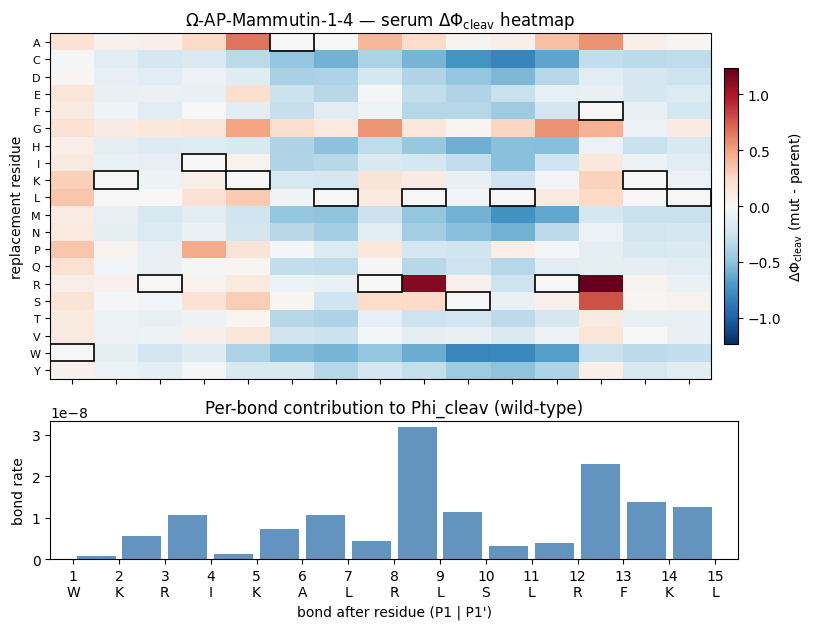

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_ap-mammutin-1-4.png


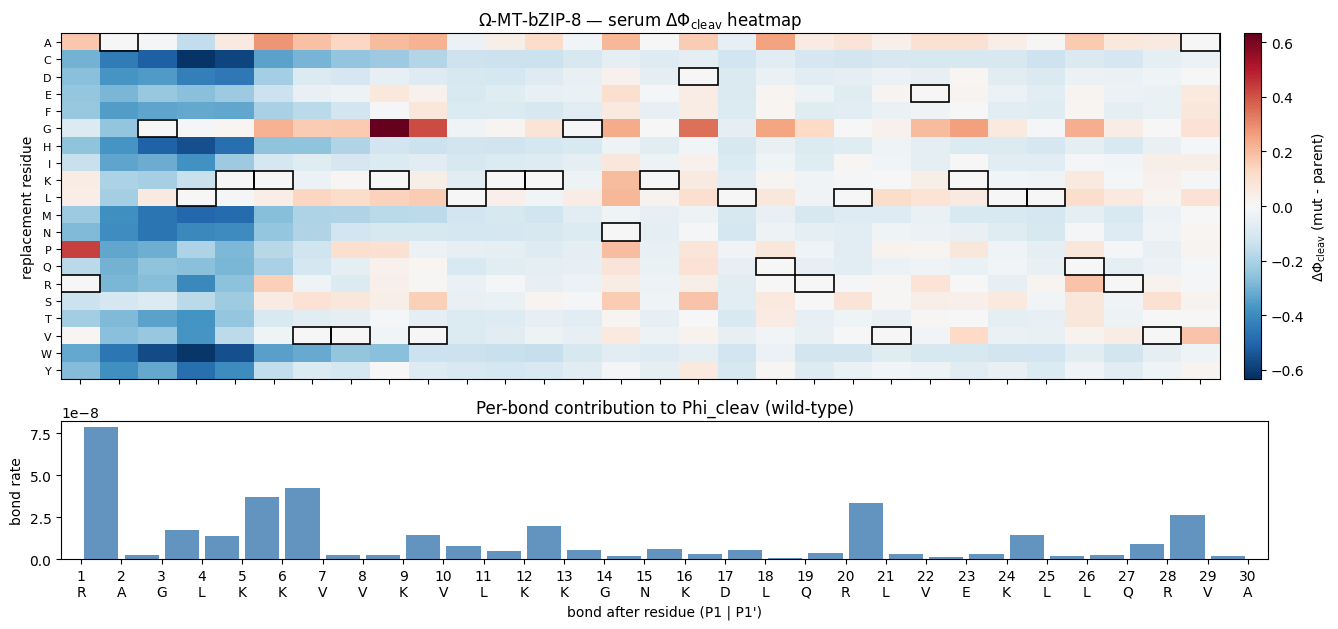

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_mt-bzip-8.png


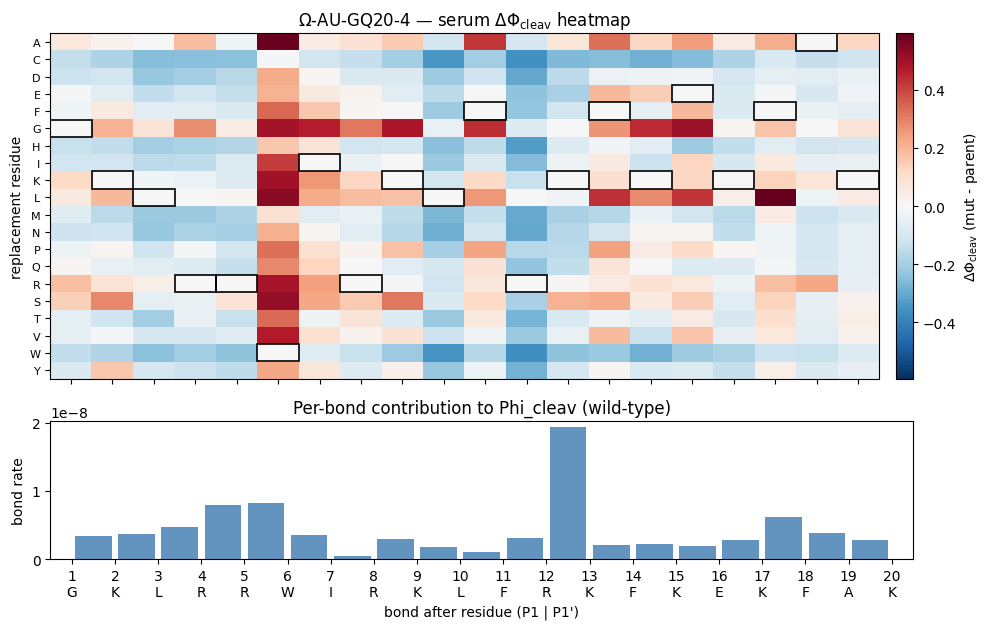

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_au-gq20-4.png


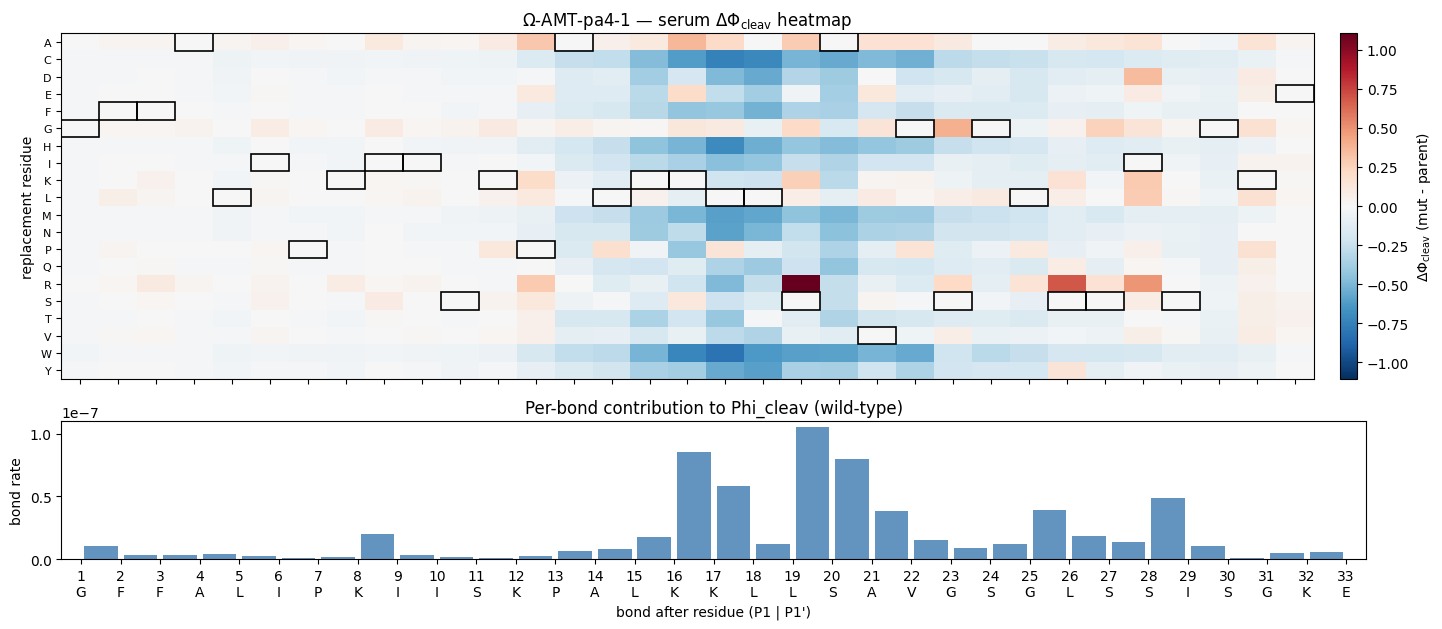

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_amt-pa4-1.png


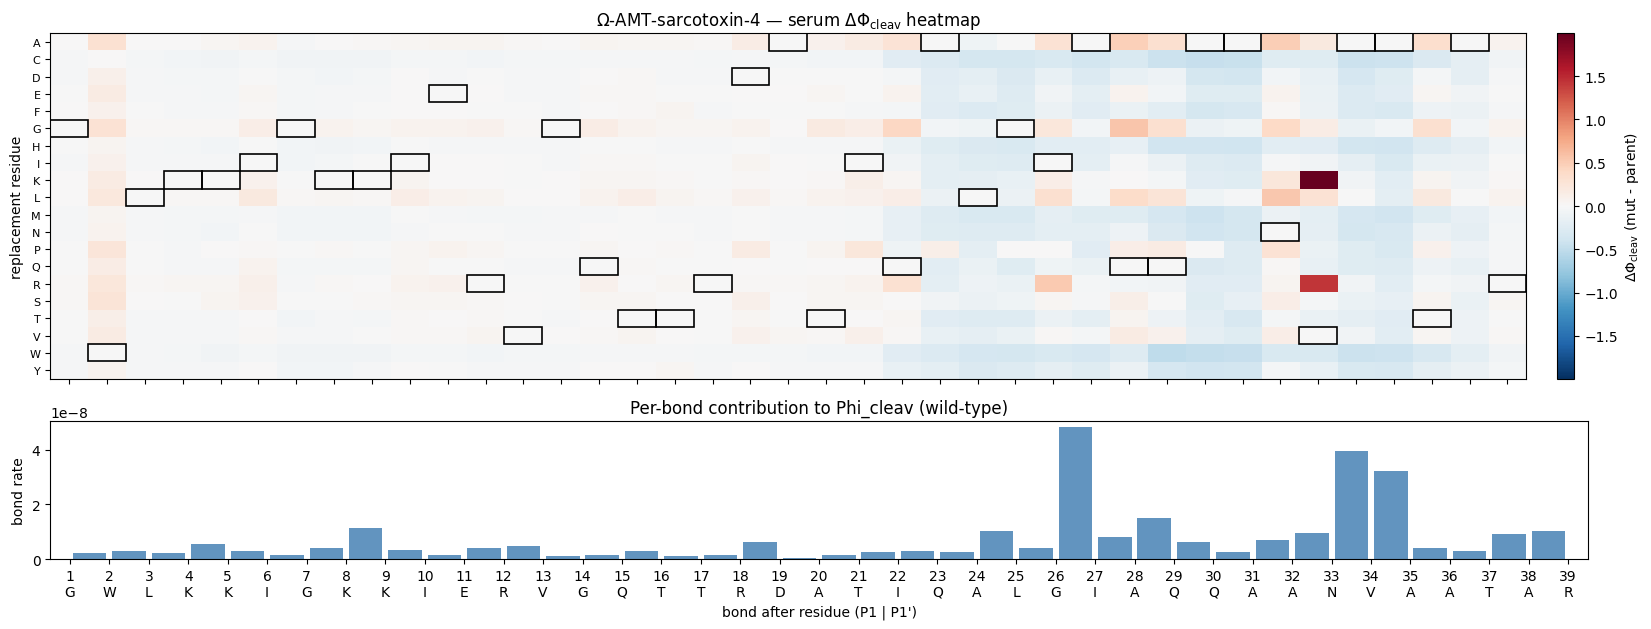

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_amt-sarcotoxin-4.png


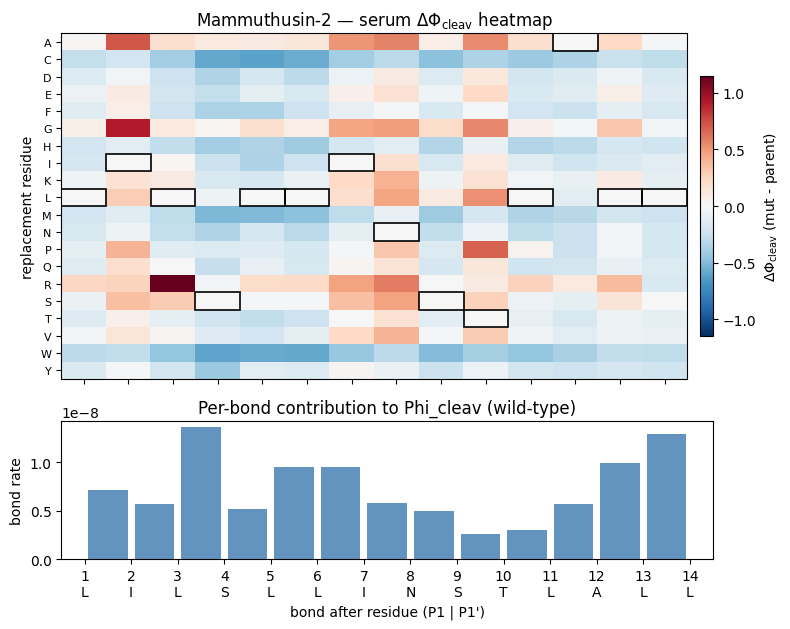

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_mammuthusin-2.png


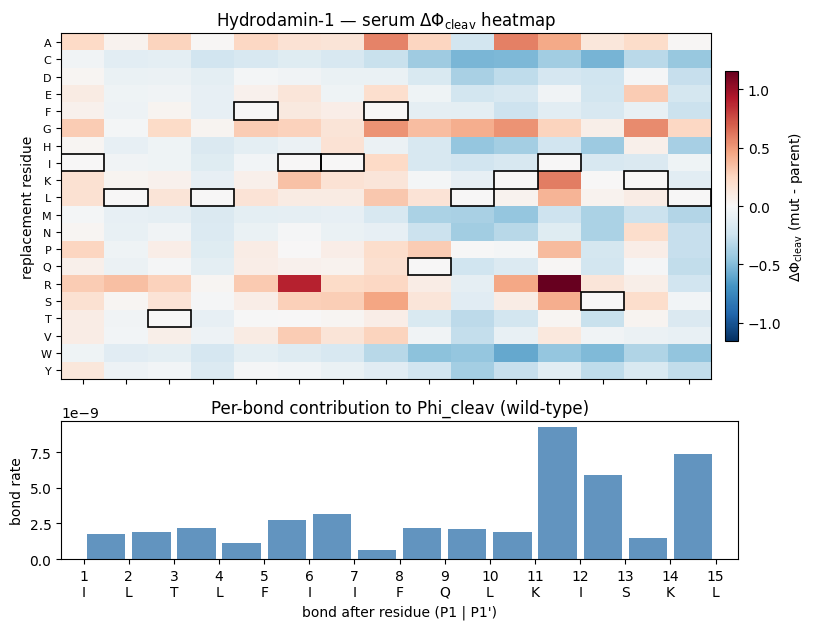

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_hydrodamin-1.png


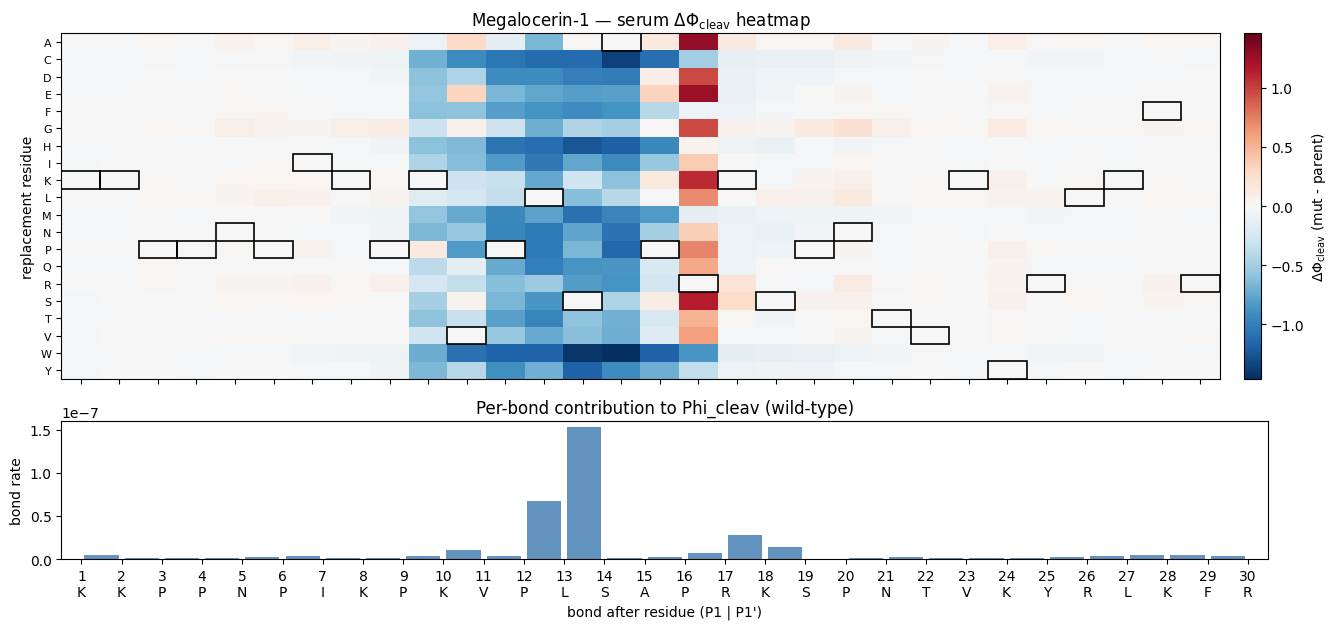

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_megalocerin-1.png


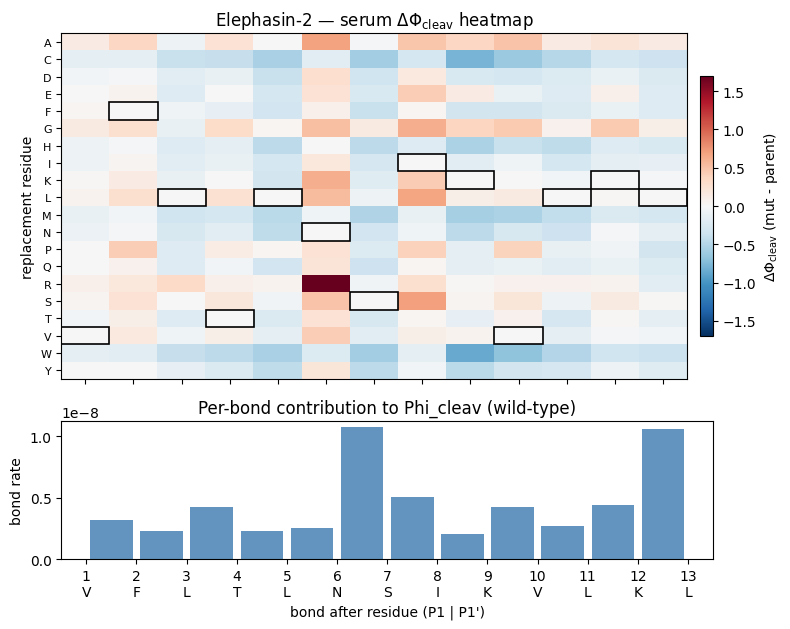

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_elephasin-2.png


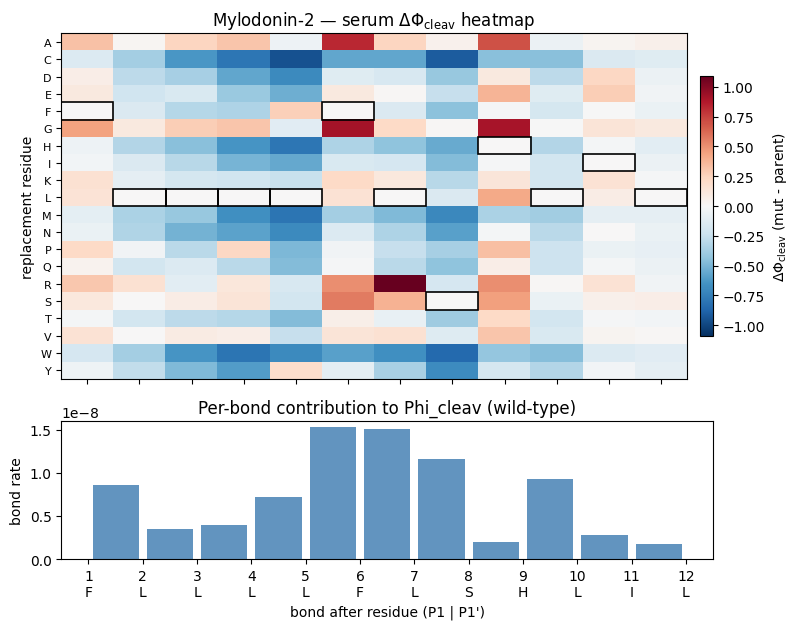

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection\heatmap_delta_cleavage_mylodonin-2.png


In [ ]:
bond_list = cleavage.sequence_bond_contributions(controls["sequence"].tolist())
controls["bond_contrib"] = bond_list

for _, row in controls.iterrows():
    name = row["name"]
    seq = row["sequence"]
    safe = (
        str(name)
        .encode("ascii", "ignore")
        .decode("ascii")
        .lower()
        .replace(" ", "_")
        .replace("/", "-")
        .strip("_-")
    )
    out = OUT_DIR / f"heatmap_delta_cleavage_{safe}.png"
    plot_control_heatmap(
        seq,
        title=rf"{name} — serum $\Delta\Phi_{{\mathrm{{cleav}}}}$ heatmap",
        out_path=out,
        known_bonds=[],
        bond_contrib=row["bond_contrib"],
    )

In [ ]:
print("Outputs in", OUT_DIR)
for path in sorted(OUT_DIR.iterdir()):
    print(" -", path.name)

Outputs in C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_serum_inspection
 - clasp_human_serum.zip
 - cleavage_and_potential_histograms.png
 - cleavage_descriptive_stats.csv
 - cleavage_histogram.png
 - dbaasp_serum_cleavage.csv
 - heatmap_delta_cleavage_amt-pa4-1.png
 - heatmap_delta_cleavage_amt-sarcotoxin-4.png
 - heatmap_delta_cleavage_ap-mammutin-1-4.png
 - heatmap_delta_cleavage_au-gq20-4.png
 - heatmap_delta_cleavage_elephasin-2.png
 - heatmap_delta_cleavage_hydrodamin-1.png
 - heatmap_delta_cleavage_mammuthusin-2.png
 - heatmap_delta_cleavage_megalocerin-1.png
 - heatmap_delta_cleavage_mt-bzip-8.png
 - heatmap_delta_cleavage_mylodonin-2.png
 - lambda_sweep_length_potential_hist_lam_0p01.png
 - lambda_sweep_length_potential_hist_lam_0p05.png
 - lambda_sweep_length_potential_hist_lam_0p1.png
 - lambda_sweep_length_potential_hist_lam_0p2.png
 - lambda_sweep_length_potential_hist_lam_0p3.png
 - lambda_sweep_length_potential_hist_lam_0p4.png
 - lambda_sweep_leng